# Unit 1: Regression

In this notebook we cover three types of regression:
1. **OLS (Ordinary Least Squares)** — predicting a continuous outcome
2. **Logistic Regression** — predicting a binary outcome
3. **Multinomial Logistic Regression** — predicting a categorical outcome with 3+ classes

For each, we will:
- Explore the data before modeling
- Fit the model and interpret the output
- Visualize coefficients with a forest plot

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

## Helper function: parse_coefs

This function extracts a coefficient dataframe from a statsmodels summary table, which we can then use for forest plots.

It works two ways:
1. Pass a **statsmodels results object** (for OLS / Logit)
2. Pass a **raw block of rows** (list of lists) from a summary table — useful for MNLogit, where the table mixes class headers with coefficient rows and you need to slice out each block yourself.

**Hint for MNLogit**: look at `results.summary().tables[1].data` to see the raw table. Row 0 is the header for the first class, then `n_features` rows of coefficients, then another header row, then the second block of coefficients. Use list slicing to grab each block.

In [5]:
def parse_coefs(results_or_block, table_index=1, rows=None, drop_const=True):
    """Extract a coefficient dataframe for forest plotting."""
    if isinstance(results_or_block, list):
        R = pd.DataFrame(results_or_block,
                         columns=["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b"])
        R[["coef", "std_err", "t", "p_val", "low_b", "up_b"]] = \
            R[["coef", "std_err", "t", "p_val", "low_b", "up_b"]].astype(float)
    else:
        R = results_or_block.summary().tables[table_index].data
        R = pd.DataFrame(R)
        R.columns = R.iloc[0]
        R = R.iloc[1:]
        if rows is not None:
            R = R.iloc[rows]
        R[R.columns[1:]] = R[R.columns[1:]].astype(float)
        R.columns = ["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b"]

    if drop_const:
        R = R[R.vari.str.strip() != "const"]
    R = R.sort_values("coef", ascending=True).reset_index(drop=True)
    p = 0.1
    R["alpha"] = (R.p_val < 0.05) * (1 - p) + p
    return R

---
# 1. OLS Regression

We will predict **median house value** in California districts using the 1990 Census data.

### 1.1 Load and explore the data

In [10]:
california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


Let's look at how the features relate to each other and to the target. A **correlation heatmap** is a quick way to spot which predictors are most associated with the outcome and whether any predictors are highly correlated with each other (multicollinearity).

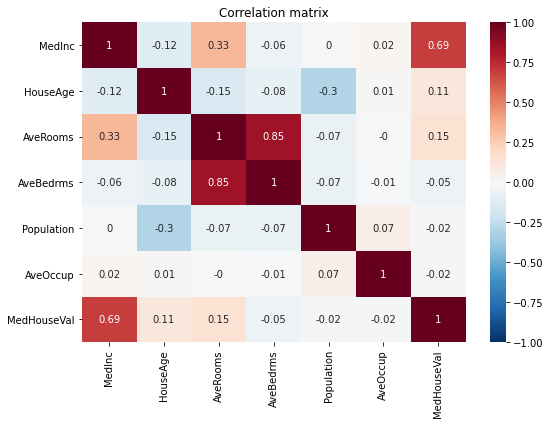

In [12]:
cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "MedHouseVal"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()

Notice that **MedInc** (median income) has the strongest correlation with house value (~0.69). Also notice that **AveRooms** and **AveBedrms** are correlated with each other (~0.85) — this is something to watch for in the regression output.

### 1.2 Fit the OLS model

In [13]:
# Define IVs and DV
X = df[["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup"]]
y = df['MedHouseVal']

# Add a constant (intercept)
X = sm.add_constant(X)

# Fit the OLS regression model
ols_model = sm.OLS(y, X)
ols_results = ols_model.fit()

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     4032.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:49:25   Log-Likelihood:                -24235.
No. Observations:               20640   AIC:                         4.848e+04
Df Residuals:                   20633   BIC:                         4.854e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4391      0.028    -15.918      0.0

### 1.3 Interpreting the output

Key things to look at:

- **R-squared = 0.54** — the model explains about 54% of the variance in house values.
- **MedInc** has the largest positive coefficient (~0.54): a one-unit increase in median income is associated with a ~$54k increase in median house value (target is in units of $100k).
- **AveRooms** has a *negative* coefficient, which seems counterintuitive. This is a sign of **multicollinearity** with AveBedrms — the two variables are highly correlated, so their individual coefficients become unstable. The model even warns us: *"The condition number is large... might indicate strong multicollinearity."*
- All coefficients are statistically significant (p < 0.05).

### 1.4 Forest plot

In [ ]:
R = parse_coefs(ols_results)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("OLS Coefficients — California Housing")
plt.tight_layout()

In [ ]:
R = parse_coefs(ols_results, drop_const=False)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("OLS Coefficients (with constant) — California Housing")
plt.tight_layout()

### 1.5 Residual diagnostics

OLS assumes that residuals are normally distributed and have constant variance (homoscedasticity). Let's check.

In [ ]:
residuals = ols_results.resid

plt.hist(residuals, bins=50, edgecolor='white')
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.tight_layout()

The residual distribution is right-skewed, which is common in real-world data. In practice you might consider robust standard errors or transforming the target.

---
# 2. Logistic Regression

Using the Titanic dataset, predict whether a passenger **survived** (binary outcome).

- **IVs**: `pclass`, `age`, `sibsp`, `fare`, `adult_male`
- **DV**: `survived`

### 2.1 Load and explore

In [16]:
df = sns.load_dataset('titanic')

x_cols = ['pclass', 'age', 'sibsp', 'fare', 'adult_male']
y_col = 'survived'

df = df[x_cols + [y_col]].dropna()
print(f"Shape after dropping NAs: {df.shape}")
print(f"\nSurvival rate: {df.survived.mean():.1%}")
df.head()

Shape after dropping NAs: (714, 6)

Survival rate: 40.6%


,pclass,age,sibsp,fare,adult_male,survived
0,3,22.0,1,7.2500,True,0
1,1,38.0,1,71.2833,False,1
2,3,26.0,0,7.9250,False,1
3,1,35.0,1,53.1000,False,1
4,3,35.0,0,8.0500,True,0


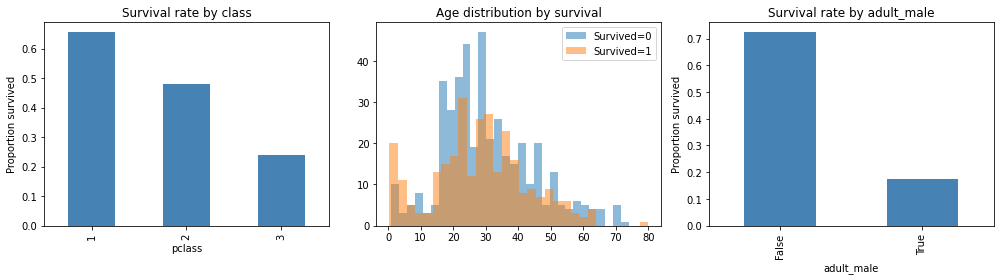

In [17]:
plt.figure(figsize=(14, 4))

# Survival by class
plt.subplot(1, 3, 1)
df.groupby('pclass')['survived'].mean().plot.bar(color='steelblue')
plt.title('Survival rate by class')
plt.ylabel('Proportion survived')

# Age distribution by survival
plt.subplot(1, 3, 2)
for survived, grp in df.groupby('survived'):
    plt.hist(grp['age'], bins=30, alpha=0.5, label=f"Survived={survived}")
plt.title('Age distribution by survival')
plt.legend()

# Survival by adult_male
plt.subplot(1, 3, 3)
df.groupby('adult_male')['survived'].mean().plot.bar(color='steelblue')
plt.title('Survival rate by adult_male')
plt.ylabel('Proportion survived')

plt.tight_layout()

### 2.2 Fit the logistic regression model

In [18]:
X = df[x_cols].copy()
X['adult_male'] = X['adult_male'].astype(int)
y = df[y_col]

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
logit_results = logit_model.fit()

print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.422273
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      708
Method:                           MLE   Df Model:                            5
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.3748
Time:                        15:50:29   Log-Likelihood:                -301.50
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 5.819e-76
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0049      0.606      8.253      0.000       3.816       6.194
pclass        -1.2419      0.

### 2.3 Interpretation

In logistic regression, coefficients are in **log-odds**. Let's convert to **odds ratios** for easier interpretation:

In [19]:
odds_ratios = pd.DataFrame({
    'coef': logit_results.params,
    'odds_ratio': np.exp(logit_results.params),
    'p_value': logit_results.pvalues
}).iloc[1:]  # drop constant

odds_ratios.round(3)

,coef,odds_ratio,p_value
pclass,-1.242,0.289,0.000
age,-0.026,0.974,0.002
sibsp,-0.613,0.542,0.000
fare,0.002,1.002,0.348
adult_male,-3.030,0.048,0.000


- **adult_male** has the largest effect: being an adult male reduces the odds of survival dramatically (OR ~ 0.05, i.e., ~95% lower odds).
- **pclass**: each step up in class number (i.e., lower class) reduces odds of survival by ~71% (OR ~ 0.29).
- **fare** is not statistically significant (p > 0.05) — once we control for class, fare doesn't add much.

### 2.4 Forest plot

In [1]:
R = parse_coefs(logit_results)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("Logistic Regression Coefficients — Titanic Survival")
plt.tight_layout()

NameError: name 'parse_coefs' is not defined

In [ ]:
R = parse_coefs(logit_results, drop_const=False)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("Logistic Regression Coefficients (with constant) — Titanic Survival")
plt.tight_layout()

### 2.5 Prediction example

In [21]:
# Predict survival probability for a specific passenger
new_passenger = pd.DataFrame({
    "const": [1],
    'pclass': [3],
    'age': [10],
    'sibsp': [0],
    'fare': [700],
    'adult_male': [0],
})

predicted_prob = logit_results.predict(new_passenger)
print(f"Predicted probability of survival: {predicted_prob[0]:.2f}")
print(f"This is a 10-year-old, non-adult-male, 3rd class passenger.")

Predicted probability of survival: 0.93
This is a 10-year-old, non-adult-male, 3rd class passenger.


---
# 3. Multinomial Logistic Regression

The UCI Wine dataset (ID 109) contains chemical properties of wines from three cultivars (classes 1, 2, 3). We'll predict the wine class from a subset of chemical features using `sm.MNLogit`.

Unlike binary logistic regression, multinomial logit estimates a separate set of coefficients **for each class** (relative to a reference class).

### 3.1 Load and explore

In [6]:
wine = fetch_ucirepo(id=109)

X = wine.data.features
X = X[['Alcohol', 'Malicacid', 'Ash', 'Nonflavanoid_phenols', 'Color_intensity', 'Alcalinity_of_ash']].astype(float)
y = wine.data.targets

print(f"Shape: {X.shape}")
print(f"\nClass distribution:\n{y.value_counts().sort_index().to_string()}")

Shape: (178, 6)

Class distribution:
class
1        59
2        71
3        48


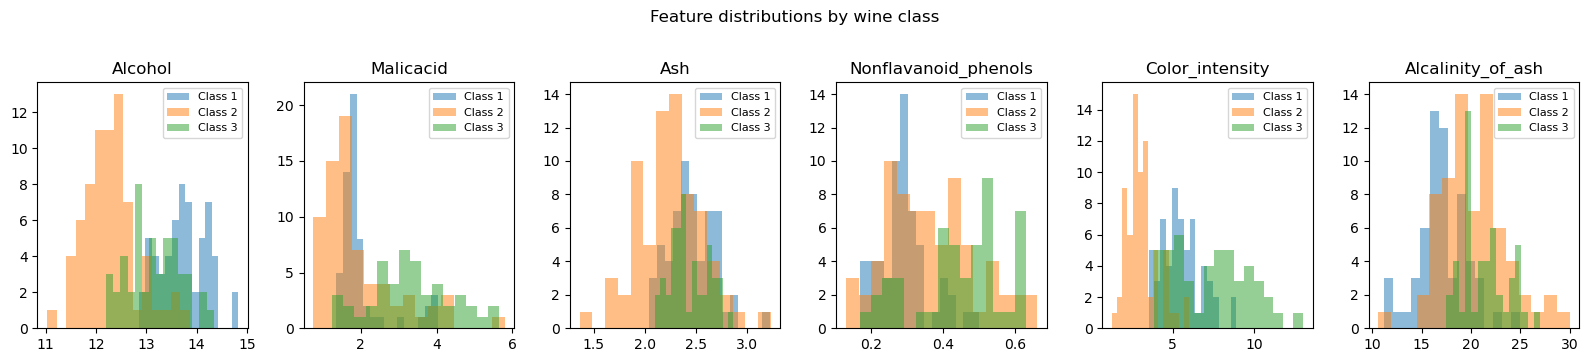

In [7]:
plt.figure(figsize=(16, 3.5))
for i, col in enumerate(X.columns):
    plt.subplot(1, len(X.columns), i + 1)
    for cls in sorted(y.iloc[:, 0].unique()):
        plt.hist(X.loc[y.iloc[:, 0] == cls, col], bins=15, alpha=0.5, label=f"Class {cls}")
    plt.title(col)
    plt.legend(fontsize=8)
plt.suptitle("Feature distributions by wine class", y=1.02)
plt.tight_layout()

### 3.2 Fit the multinomial model

In [8]:
X_model = sm.add_constant(X)

multinomial_model = sm.MNLogit(y, X_model)
multinomial_results = multinomial_model.fit()

print(multinomial_results.summary())

Optimization terminated successfully.
         Current function value: 0.090755
         Iterations 13
                          MNLogit Regression Results                          
Dep. Variable:                  class   No. Observations:                  178
Model:                        MNLogit   Df Residuals:                      164
Method:                           MLE   Df Model:                           12
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                  0.9164
Time:                        20:44:13   Log-Likelihood:                -16.154
converged:                       True   LL-Null:                       -193.31
Covariance Type:            nonrobust   LLR p-value:                 1.719e-68
             class=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  200.7031     64.513      3.111      0.002      74.261     327.14

### 3.3 Interpretation

- The reference category is **class 1**. Each set of coefficients tells us how predictors shift the log-odds of being in that class vs. class 1.
- **Pseudo R-squared ~ 0.92** indicates very strong discriminative power.
- **Alcohol** and **Ash** have large negative coefficients for class 2 vs 1 — higher values make class 2 less likely.
- **Nonflavanoid_phenols** has a large positive coefficient in both comparisons — higher values push toward classes 2 and 3.
- **Color_intensity** flips sign: negative for class 2 vs 1, positive for class 3 vs 1 — it helps distinguish all three classes.
- Most coefficients are statistically significant (p < 0.05), unlike the original 4-variable model.

### 3.4 Forest plots — both classes on one figure

Since multinomial logit gives us two sets of coefficients (class 2 vs 1 and class 3 vs 1), we can overlay them on a single plot for comparison.

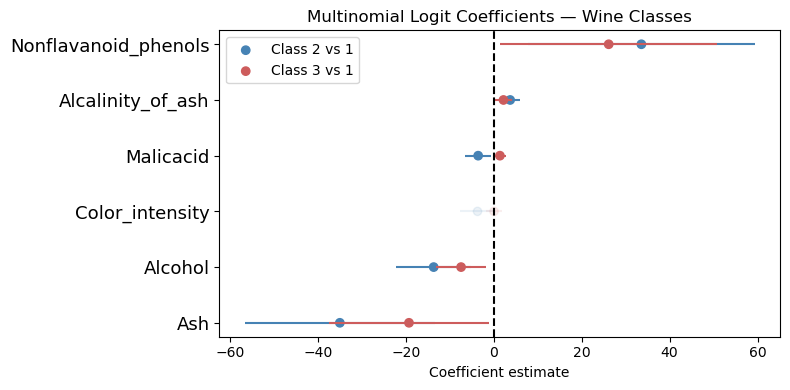

In [9]:
# The MNLogit summary table interleaves class headers with coefficient rows.
# We need to parse out the two groups manually.
tbl = multinomial_results.summary().tables[1].data

# Find where each class block starts by looking for header rows
n_features = len(X_model.columns)  # const + 6 features = 7

# Class 2 vs 1: rows 1..n_features (row 0 is the class label header)
# Class 3 vs 1: rows (n_features+1)+1 .. end (another header in between)
block1 = tbl[1:n_features + 1]
block2 = tbl[n_features + 2:]

R1 = parse_coefs(block1)
R2 = parse_coefs(block2)

plt.figure(figsize=(8, 4))
plt.hlines(R1.index, R1.low_b, R1.up_b, alpha=R1.alpha, color='steelblue')
plt.scatter(R1.coef, R1.index, alpha=R1.alpha, color='steelblue', label='Class 2 vs 1')
plt.hlines(R2.index, R2.low_b, R2.up_b, alpha=R2.alpha, color='indianred')
plt.scatter(R2.coef, R2.index, alpha=R2.alpha, color='indianred', label='Class 3 vs 1')
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R1.index, R1.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.legend()
plt.title("Multinomial Logit Coefficients — Wine Classes")
plt.tight_layout()

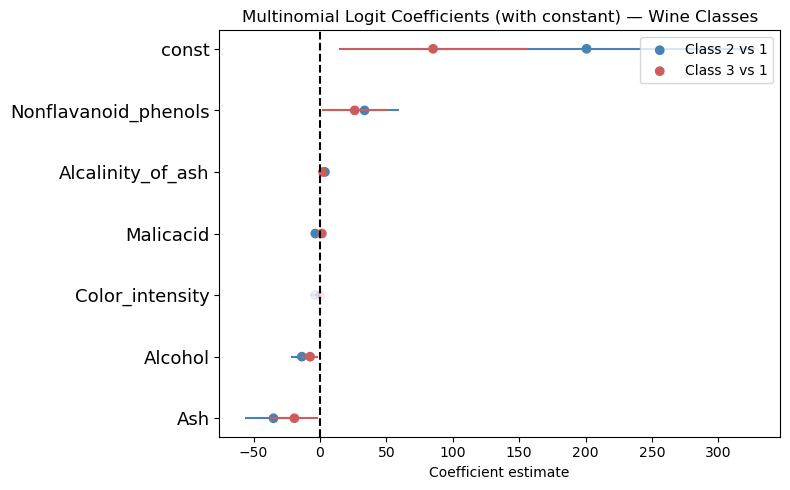

In [10]:
R1 = parse_coefs(block1, drop_const=False)
R2 = parse_coefs(block2, drop_const=False)

plt.figure(figsize=(8, 5))
plt.hlines(R1.index, R1.low_b, R1.up_b, alpha=R1.alpha, color='steelblue')
plt.scatter(R1.coef, R1.index, alpha=R1.alpha, color='steelblue', label='Class 2 vs 1')
plt.hlines(R2.index, R2.low_b, R2.up_b, alpha=R2.alpha, color='indianred')
plt.scatter(R2.coef, R2.index, alpha=R2.alpha, color='indianred', label='Class 3 vs 1')
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R1.index, R1.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.legend()
plt.title("Multinomial Logit Coefficients (with constant) — Wine Classes")
plt.tight_layout()